Dimensions initiales : (89293, 22)

Colonnes initiales :
['datetime', 'station', 'lat', 'lon', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'std_3*3_TB_4', 'std_3*3_TB_5', 'std_3*3_TB_6', 'std_3*3_TB_7', 'std_3*3_TB_8', 'std_3*3_TB_9', 'std_3*3_TB_10', 'std_3*3_TB_11', 'fls_station_cf', 'fls_station_hc']

Nombre de stations uniques : 11

=== Vérification des valeurs manquantes ===
TB4        1
TB1_TB2    1
TB4_TB9    1
TB9_TB4    1
dtype: int64

Nombre total de valeurs manquantes : 4
Dimensions après suppression des valeurs manquantes : (89292, 28)

=== Statistiques des nouvelles colonnes ===
            TB1_TB2       TB4_TB9      TB10_TB9       TB9_TB4       TB9_TB5  \
count  89292.000000  89292.000000  89292.000000  89292.000000  89292.000000   
mean      47.167335      1.673775     -1.161361     -1.673775     45.493561   
std       12.360528      6.641929      1.180763      6.641929     12.753872   
min       -6.676560     -7.761093    -10.927063    -58.260574     -1.58

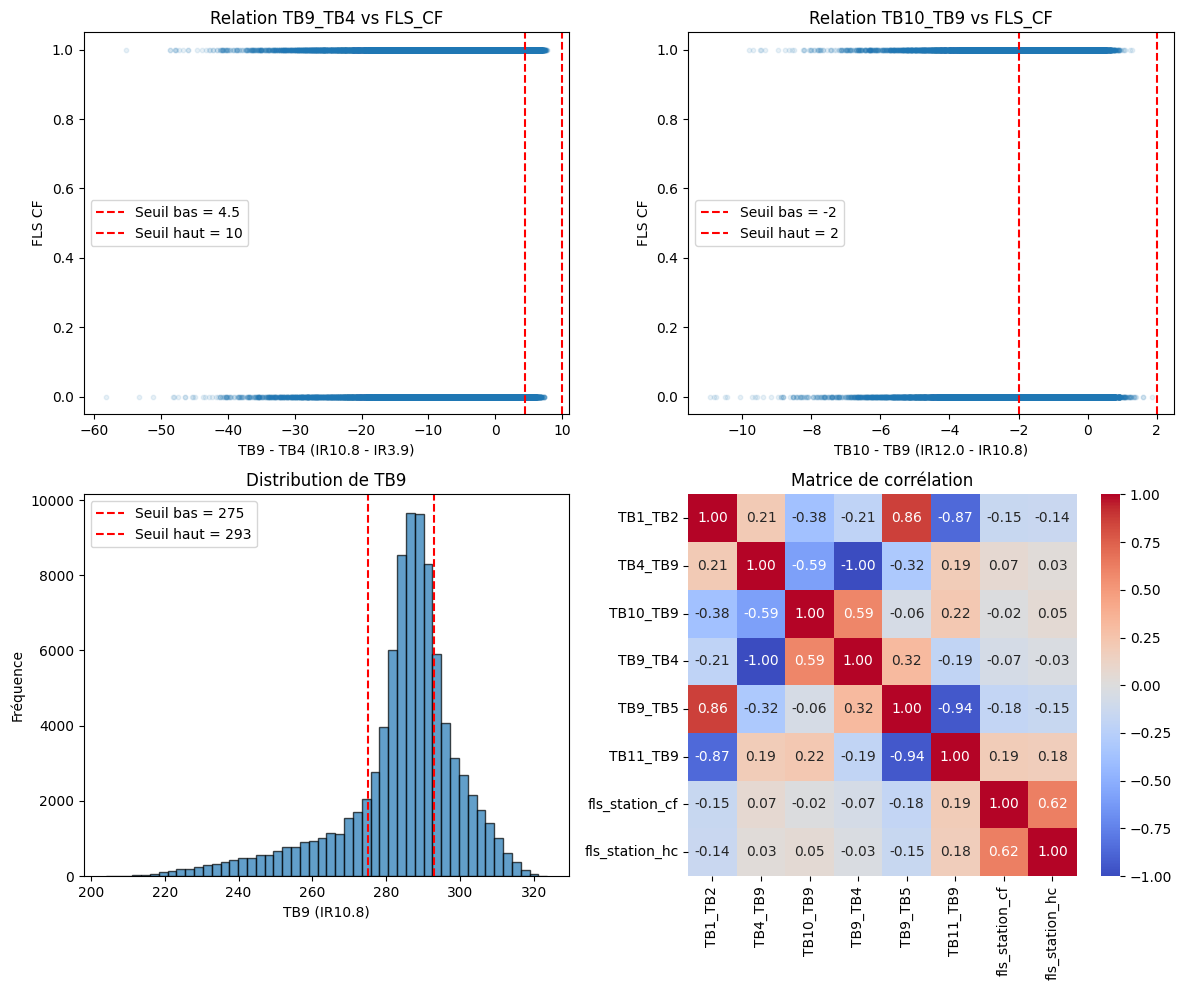


=== Structure finale des données ===
Nombre total d'observations : 89292
Nombre de colonnes : 28

Colonnes disponibles après préparation :
['datetime', 'station', 'lat', 'lon', 'TB4', 'TB5', 'TB6', 'TB7', 'TB8', 'TB9', 'TB10', 'TB11', 'std_3*3_TB_4', 'std_3*3_TB_5', 'std_3*3_TB_6', 'std_3*3_TB_7', 'std_3*3_TB_8', 'std_3*3_TB_9', 'std_3*3_TB_10', 'std_3*3_TB_11', 'fls_station_cf', 'fls_station_hc', 'TB1_TB2', 'TB4_TB9', 'TB10_TB9', 'TB9_TB4', 'TB9_TB5', 'TB11_TB9']

Données préparées sauvegardées dans : C:\Users\moham\OneDrive\Documents\fog\data_ML_xgboost_prepared.csv

=== Échantillon des données préparées ===
    datetime         station   TB9_TB4  TB10_TB9         TB9  fls_station_cf  \
0 2024-01-01  AGADIR-MASSIRA  2.092075 -0.573975  279.538605             0.0   
1 2024-01-01      AL-HOCEIMA -2.737547 -0.907715  244.043213             0.0   
2 2024-01-01         KENITRA -4.423474 -1.302338  250.544006             1.0   
3 2024-01-01        LAAYOUNE  0.756197 -0.418213  279.832947 

In [1]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Charger les données
file_path = Path(r"C:\Users\moham\OneDrive\Documents\fog\data_ML_xgboost (2).csv")
df = pd.read_csv(file_path, parse_dates=['datetime'])

print(f"Dimensions initiales : {df.shape}")
print("\nColonnes initiales :")
print(df.columns.tolist())
print(f"\nNombre de stations uniques : {df['station'].nunique()}")

# 2. Ajouter les différences de température de brillance
# Note: TB4 = IR3.9, TB9 = IR10.8, TB10 = IR12.0, etc.

# Différences spécifiques demandées
df['TB1_TB2'] = df['TB4'] - df['TB5']  # IR3.9 - IR8.7
df['TB4_TB9'] = df['TB4'] - df['TB9']  # IR3.9 - IR10.8

# Autres différences importantes pour la détection FLS (basées sur la littérature)
df['TB10_TB9'] = df['TB10'] - df['TB9']    # IR12.0 - IR10.8 (pour épaisseur optique)
df['TB9_TB4'] = df['TB9'] - df['TB4']      # IR10.8 - IR3.9 (pour phase du nuage)
df['TB9_TB5'] = df['TB9'] - df['TB5']      # IR10.8 - IR8.7
df['TB11_TB9'] = df['TB11'] - df['TB9']    # IR13.4 - IR10.8

# 3. Vérifier et gérer les valeurs manquantes
print("\n=== Vérification des valeurs manquantes ===")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

if df.isnull().any().any():
    print(f"\nNombre total de valeurs manquantes : {df.isnull().sum().sum()}")
    # Supprimer les lignes avec valeurs manquantes (ou utiliser une autre stratégie)
    df = df.dropna()
    print(f"Dimensions après suppression des valeurs manquantes : {df.shape}")

# 4. Analyse statistique des nouvelles colonnes
print("\n=== Statistiques des nouvelles colonnes ===")
new_columns = ['TB1_TB2', 'TB4_TB9', 'TB10_TB9', 'TB9_TB4', 'TB9_TB5', 'TB11_TB9']
print(df[new_columns].describe())

# 5. Distribution des variables cibles
print("\n=== Distribution des variables cibles ===")
print("Configuration CF (Contraintes Faibles):")
print(df['fls_station_cf'].value_counts(normalize=True))
print("\nConfiguration HC (Contraintes Fortes):")
print(df['fls_station_hc'].value_counts(normalize=True))

# 6. Visualisation des relations clés
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Relation entre TB9_TB4 et FLS_CF
axes[0, 0].scatter(df['TB9_TB4'], df['fls_station_cf'], alpha=0.1, s=10)
axes[0, 0].axvline(x=4.5, color='r', linestyle='--', label='Seuil bas = 4.5')
axes[0, 0].axvline(x=10, color='r', linestyle='--', label='Seuil haut = 10')
axes[0, 0].set_xlabel('TB9 - TB4 (IR10.8 - IR3.9)')
axes[0, 0].set_ylabel('FLS CF')
axes[0, 0].set_title('Relation TB9_TB4 vs FLS_CF')
axes[0, 0].legend()

# Relation entre TB10_TB9 et FLS_CF
axes[0, 1].scatter(df['TB10_TB9'], df['fls_station_cf'], alpha=0.1, s=10)
axes[0, 1].axvline(x=-2, color='r', linestyle='--', label='Seuil bas = -2')
axes[0, 1].axvline(x=2, color='r', linestyle='--', label='Seuil haut = 2')
axes[0, 1].set_xlabel('TB10 - TB9 (IR12.0 - IR10.8)')
axes[0, 1].set_ylabel('FLS CF')
axes[0, 1].set_title('Relation TB10_TB9 vs FLS_CF')
axes[0, 1].legend()

# Distribution de TB9
axes[1, 0].hist(df['TB9'], bins=50, alpha=0.7, edgecolor='black')
axes[1, 0].axvline(x=275, color='r', linestyle='--', label='Seuil bas = 275')
axes[1, 0].axvline(x=293, color='r', linestyle='--', label='Seuil haut = 293')
axes[1, 0].set_xlabel('TB9 (IR10.8)')
axes[1, 0].set_ylabel('Fréquence')
axes[1, 0].set_title('Distribution de TB9')
axes[1, 0].legend()

# Matrice de corrélation des nouvelles variables
corr_matrix = df[new_columns + ['fls_station_cf', 'fls_station_hc']].corr()
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=axes[1, 1])
axes[1, 1].set_title('Matrice de corrélation')

plt.tight_layout()
plt.show()

# 7. Structure finale des données
print("\n=== Structure finale des données ===")
print(f"Nombre total d'observations : {len(df)}")
print(f"Nombre de colonnes : {len(df.columns)}")
print("\nColonnes disponibles après préparation :")
print(df.columns.tolist())

# 8. Exporter le DataFrame préparé (optionnel)
output_path = file_path.parent / "data_ML_xgboost_prepared.csv"
df.to_csv(output_path, index=False)
print(f"\nDonnées préparées sauvegardées dans : {output_path}")

# 9. Afficher un échantillon des données
print("\n=== Échantillon des données préparées ===")
sample_columns = ['datetime', 'station', 'TB9_TB4', 'TB10_TB9', 'TB9', 
                  'fls_station_cf', 'fls_station_hc']
print(df[sample_columns].head(10))

In [5]:
# Importation des bibliothèques nécessaires
import xgboost as xgb
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                            f1_score, roc_auc_score, confusion_matrix, 
                            classification_report, roc_curve, auc)
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import warnings

# Ignorer les warnings pour une lecture plus propre
warnings.filterwarnings('ignore')

In [6]:
# Caractéristiques de base - ce sont les températures de brillance individuelles
base_features = ['TB4', 'TB5', 'TB9', 'TB10', 'TB11']
print("Caractéristiques de base (TB individuelles) :")
for f in base_features:
    print(f"  - {f}")

# Caractéristiques dérivées - ce sont les différences entre canaux
derived_features = ['TB1_TB2', 'TB4_TB9', 'TB10_TB9', 
                    'TB9_TB4', 'TB9_TB5', 'TB11_TB9']
print("\nCaractéristiques dérivées (différences) :")
for f in derived_features:
    print(f"  - {f}")

# Caractéristiques statistiques - ce sont les écarts-types locaux
std_features = [col for col in df.columns if 'std_3' in col]
print("\nCaractéristiques statistiques (écarts-types locaux) :")
for f in std_features:
    print(f"  - {f}")

# Combiner toutes les caractéristiques
features = base_features + derived_features + std_features
print(f"\nNombre total de caractéristiques : {len(features)}")

Caractéristiques de base (TB individuelles) :
  - TB4
  - TB5
  - TB9
  - TB10
  - TB11

Caractéristiques dérivées (différences) :
  - TB1_TB2
  - TB4_TB9
  - TB10_TB9
  - TB9_TB4
  - TB9_TB5
  - TB11_TB9

Caractéristiques statistiques (écarts-types locaux) :
  - std_3*3_TB_4
  - std_3*3_TB_5
  - std_3*3_TB_6
  - std_3*3_TB_7
  - std_3*3_TB_8
  - std_3*3_TB_9
  - std_3*3_TB_10
  - std_3*3_TB_11

Nombre total de caractéristiques : 19


In [7]:
# Séparer les variables prédictives (X) et les variables cibles (y)
X = df[features]  # Toutes nos caractéristiques
y_cf = df['fls_station_cf']  # Variable cible pour Contraintes Faibles
y_hc = df['fls_station_hc']  # Variable cible pour Contraintes Fortes

print(f"Dimensions de X : {X.shape}")
print(f"  - Nombre d'observations : {X.shape[0]}")
print(f"  - Nombre de caractéristiques : {X.shape[1]}")
print(f"\nDistribution des classes :")
print(f"  - FLS_CF = 1 : {y_cf.mean():.3%} ({y_cf.sum()} événements sur {len(y_cf)})")
print(f"  - FLS_HC = 1 : {y_hc.mean():.3%} ({y_hc.sum()} événements sur {len(y_hc)})")

Dimensions de X : (89292, 19)
  - Nombre d'observations : 89292
  - Nombre de caractéristiques : 19

Distribution des classes :
  - FLS_CF = 1 : 39.833% (35568.0 événements sur 89292)
  - FLS_HC = 1 : 20.343% (18165.0 événements sur 89292)


In [8]:
# La normalisation est importante pour que toutes les caractéristiques aient la même échelle
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)  # Standardise les données (moyenne=0, écart-type=1)
X_scaled_df = pd.DataFrame(X_scaled, columns=features)

print("Normalisation effectuée :")
print("  - Moyenne après normalisation :", X_scaled_df.mean().mean())
print("  - Écart-type après normalisation :", X_scaled_df.std().mean())
print("\nAperçu des données normalisées :")
print(X_scaled_df.head())

Normalisation effectuée :
  - Moyenne après normalisation : -6.64745960738176e-17
  - Écart-type après normalisation : 1.0000055996528217

Aperçu des données normalisées :
        TB4       TB5       TB9      TB10      TB11   TB1_TB2   TB4_TB9  \
0 -0.571591 -0.235823 -0.285187 -0.246453 -0.041404 -0.556356 -0.566984   
1 -2.672147 -1.456589 -2.496013 -2.458785 -2.487066 -2.422598  0.160161   
2 -2.111370 -1.310419 -2.091112 -2.081749 -2.046400 -1.833870  0.413993   
3 -0.459924 -0.731977 -0.266854 -0.218661  0.015007 -0.174628 -0.365855   
4 -0.557229 -0.662877 -0.266854 -0.209420 -0.064049 -0.324351 -0.579733   

   TB10_TB9   TB9_TB4   TB9_TB5  TB11_TB9  std_3*3_TB_4  std_3*3_TB_5  \
0  0.497467  0.566984 -0.243924  0.664264     -0.605753     -0.408407   
1  0.214817 -0.160161 -2.431290  2.225089      1.242734     -0.072855   
2 -0.119395 -0.413993 -1.992910  1.926996     -0.227575      0.230867   
3  0.629384  0.365855  0.021287  0.712347     -0.495153     -0.547140   
4  0.756132 

In [9]:
# Pour CF (Contraintes Faibles)
X_train_cf, X_test_cf, y_train_cf, y_test_cf = train_test_split(
    X_scaled_df,  # Données normalisées
    y_cf,         # Variable cible CF
    test_size=0.2,        # 20% pour le test
    stratify=y_cf,        # Maintient la proportion de FLS dans train et test
    random_state=42       # Pour la reproductibilité
)

# Pour HC (Contraintes Fortes)
X_train_hc, X_test_hc, y_train_hc, y_test_hc = train_test_split(
    X_scaled_df,  # Données normalisées
    y_hc,         # Variable cible HC
    test_size=0.2,        # 20% pour le test
    stratify=y_hc,        # Maintient la proportion de FLS dans train et test
    random_state=42       # Pour la reproductibilité
)

print("Taille des ensembles pour CF :")
print(f"  - Entraînement : {len(X_train_cf)} observations")
print(f"  - Test : {len(X_test_cf)} observations")
print(f"\nTaille des ensembles pour HC :")
print(f"  - Entraînement : {len(X_train_hc)} observations")
print(f"  - Test : {len(X_test_hc)} observations")

Taille des ensembles pour CF :
  - Entraînement : 71433 observations
  - Test : 17859 observations

Taille des ensembles pour HC :
  - Entraînement : 71433 observations
  - Test : 17859 observations


In [11]:
def calculate_weather_metrics(y_true, y_pred, y_pred_proba=None):
    """
    Calcule les métriques spécifiques à la météorologie
    à partir des prédictions et des valeurs réelles
    
    Paramètres :
    ------------
    y_true : valeurs réelles
    y_pred : prédictions du modèle
    y_pred_proba : probabilités de prédiction (optionnel)
    
    Retourne :
    ----------
    Dictionnaire avec toutes les métriques
    """
    # Calcul de la matrice de confusion
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    
    # Métriques standard
    accuracy = accuracy_score(y_true, y_pred)  # Exactitude globale
    precision = precision_score(y_true, y_pred, zero_division=0)  # Précision
    recall = recall_score(y_true, y_pred, zero_division=0)  # Rappel
    
    # Métriques météorologiques
    pod = tp / (tp + fn) if (tp + fn) > 0 else 0  # Probability Of Detection
    far = fp / (tp + fp) if (tp + fp) > 0 else 0  # False Alarm Ratio
    fbias = (tp + fp) / (tp + fn) if (tp + fn) > 0 else 0  # Frequency Bias
    
    # Heidke Skill Score (HSS) - mesure l'amélioration par rapport au hasard
    total = tn + fp + fn + tp
    expected_correct = ((tp + fn)*(tp + fp) + (tn + fn)*(tn + fp)) / total
    hss = (tp + tn - expected_correct) / (total - expected_correct) if (total - expected_correct) > 0 else 0
    
    # ROC-AUC si probabilités disponibles
    if y_pred_proba is not None:
        roc_auc = roc_auc_score(y_true, y_pred_proba)
    else:
        roc_auc = None
    
    # Compilation des résultats
    metrics = {
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'POD': pod,
        'FAR': far,
        'FBIAS': fbias,
        'HSS': hss,
        'ROC-AUC': roc_auc,
        'Confusion_Matrix': [[tn, fp], [fn, tp]]
    }
    
    return metrics

# Test de la fonction avec un exemple simple
print("Exemple de calcul des métriques :")
sample_true = [0, 1, 0, 1, 0, 1]
sample_pred = [0, 1, 0, 0, 0, 1]
sample_metrics = calculate_weather_metrics(sample_true, sample_pred)

# Afficher les métriques avec formatage adapté
for key, value in sample_metrics.items():
    if key != 'Confusion_Matrix':
        if value is None:
            print(f"  {key}: Non disponible")
        else:
            print(f"  {key}: {value:.3f}")

Exemple de calcul des métriques :
  Accuracy: 0.833
  Precision: 1.000
  Recall: 0.667
  F1-Score: 0.800
  POD: 0.667
  FAR: 0.000
  FBIAS: 0.667
  HSS: 0.667
  ROC-AUC: Non disponible


In [13]:
print("="*60)
print("ENTRAÎNEMENT DU MODÈLE - CONFIGURATION CF")
print("="*60)

# Configuration du modèle XGBoost pour CF
model_cf = xgb.XGBClassifier(
    objective='binary:logistic',  # Classification binaire
    eval_metric='logloss',         # Métrique d'évaluation
    use_label_encoder=False,       # Ne pas utiliser l'encodeur de labels
    random_state=42,               # Pour la reproductibilité
    # Pondération pour gérer le déséquilibre des classes
    scale_pos_weight=len(y_train_cf[y_train_cf==0]) / len(y_train_cf[y_train_cf==1])
)

print("Configuration initiale du modèle CF :")
print(f"  - Objectif : {model_cf.objective}")
print(f"  - Pondération des classes positives : {model_cf.scale_pos_weight:.2f}")

# Définition de la grille d'hyperparamètres à tester
param_grid = {
    'max_depth': [3, 5, 7],           # Profondeur maximale des arbres
    'learning_rate': [0.01, 0.05, 0.1], # Taux d'apprentissage
    'n_estimators': [100, 200],       # Nombre d'arbres
    'subsample': [0.8, 1.0],          # Pourcentage d'échantillons utilisés
    'colsample_bytree': [0.8, 1.0]    # Pourcentage de caractéristiques utilisées
}

print("\nGrille d'hyperparamètres à tester :")
for param, values in param_grid.items():
    print(f"  - {param}: {values}")

# Configuration de la validation croisée
cv = StratifiedKFold(
    n_splits=3,        # 3 plis pour la validation croisée
    shuffle=True,       # Mélanger les données
    random_state=42     # Pour la reproductibilité
)

print(f"\nValidation croisée : {cv.n_splits} plis")

# Configuration de la recherche de grille
grid_search_cf = GridSearchCV(
    estimator=model_cf,      # Modèle à optimiser
    param_grid=param_grid,   # Grille d'hyperparamètres
    cv=cv,                   # Stratégie de validation croisée
    scoring='roc_auc',       # Métrique à optimiser (ROC-AUC)
    n_jobs=-1,               # Utiliser tous les cœurs CPU
    verbose=1                # Afficher la progression
)

ENTRAÎNEMENT DU MODÈLE - CONFIGURATION CF
Configuration initiale du modèle CF :
  - Objectif : binary:logistic
  - Pondération des classes positives : 1.51

Grille d'hyperparamètres à tester :
  - max_depth: [3, 5, 7]
  - learning_rate: [0.01, 0.05, 0.1]
  - n_estimators: [100, 200]
  - subsample: [0.8, 1.0]
  - colsample_bytree: [0.8, 1.0]

Validation croisée : 3 plis


In [14]:
print("Début de la recherche d'hyperparamètres pour CF...")
print("Cette opération peut prendre quelques minutes...")

# Lancer la recherche d'hyperparamètres
grid_search_cf.fit(X_train_cf, y_train_cf)

print("\nRecherche terminée !")
print(f"Meilleurs hyperparamètres CF : {grid_search_cf.best_params_}")
print(f"Meilleur score ROC-AUC (validation croisée) : {grid_search_cf.best_score_:.4f}")

# Récupérer le meilleur modèle
best_model_cf = grid_search_cf.best_estimator_
print(f"\nMeilleur modèle CF sauvegardé dans 'best_model_cf'")

Début de la recherche d'hyperparamètres pour CF...
Cette opération peut prendre quelques minutes...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Recherche terminée !
Meilleurs hyperparamètres CF : {'colsample_bytree': 1.0, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Meilleur score ROC-AUC (validation croisée) : 0.7813

Meilleur modèle CF sauvegardé dans 'best_model_cf'


In [15]:
print("="*60)
print("ENTRAÎNEMENT DU MODÈLE - CONFIGURATION HC")
print("="*60)

# Configuration du modèle XGBoost pour HC (même principe que CF)
model_hc = xgb.XGBClassifier(
    objective='binary:logistic',
    eval_metric='logloss',
    use_label_encoder=False,
    random_state=42,
    # Note: la pondération est différente car les classes sont différentes pour HC
    scale_pos_weight=len(y_train_hc[y_train_hc==0]) / len(y_train_hc[y_train_hc==1])
)

print("Configuration initiale du modèle HC :")
print(f"  - Objectif : {model_hc.objective}")
print(f"  - Pondération des classes positives : {model_hc.scale_pos_weight:.2f}")

# Même grille d'hyperparamètres
print("\nMême grille d'hyperparamètres utilisée que pour CF")

# Configuration de la recherche de grille pour HC
grid_search_hc = GridSearchCV(
    estimator=model_hc,
    param_grid=param_grid,  # Même grille
    cv=cv,                  # Même validation croisée
    scoring='roc_auc',
    n_jobs=-1,
    verbose=1
)

ENTRAÎNEMENT DU MODÈLE - CONFIGURATION HC
Configuration initiale du modèle HC :
  - Objectif : binary:logistic
  - Pondération des classes positives : 3.92

Même grille d'hyperparamètres utilisée que pour CF


In [16]:
print("Début de la recherche d'hyperparamètres pour HC...")
print("Cette opération peut prendre quelques minutes...")

# Lancer la recherche d'hyperparamètres
grid_search_hc.fit(X_train_hc, y_train_hc)

print("\nRecherche terminée !")
print(f"Meilleurs hyperparamètres HC : {grid_search_hc.best_params_}")
print(f"Meilleur score ROC-AUC (validation croisée) : {grid_search_hc.best_score_:.4f}")

# Récupérer le meilleur modèle
best_model_hc = grid_search_hc.best_estimator_
print(f"\nMeilleur modèle HC sauvegardé dans 'best_model_hc'")

Début de la recherche d'hyperparamètres pour HC...
Cette opération peut prendre quelques minutes...
Fitting 3 folds for each of 72 candidates, totalling 216 fits

Recherche terminée !
Meilleurs hyperparamètres HC : {'colsample_bytree': 0.8, 'learning_rate': 0.05, 'max_depth': 7, 'n_estimators': 200, 'subsample': 0.8}
Meilleur score ROC-AUC (validation croisée) : 0.8147

Meilleur modèle HC sauvegardé dans 'best_model_hc'


In [17]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Évalue un modèle et affiche les résultats détaillés
    """
    print(f"\n{'='*60}")
    print(f"ÉVALUATION DU MODÈLE {model_name}")
    print(f"{'='*60}")
    
    # Faire les prédictions
    y_pred = model.predict(X_test)  # Prédictions de classe (0 ou 1)
    y_pred_proba = model.predict_proba(X_test)[:, 1]  # Probabilités pour classe 1
    
    # Calculer toutes les métriques
    metrics = calculate_weather_metrics(y_test, y_pred, y_pred_proba)
    
    # Afficher les résultats
    print("MÉTRIQUES DE PERFORMANCE :")
    print("-" * 40)
    
    # Métriques principales
    metric_names = {
        'Accuracy': 'Exactitude globale',
        'Precision': 'Précision',
        'Recall': 'Rappel',
        'F1-Score': 'Score F1',
        'POD': 'Probabilité de Détection (POD)',
        'FAR': 'Taux de Fausses Alertes (FAR)',
        'FBIAS': 'Facteur de Biais (FBIAS)',
        'HSS': 'Score de Heidke (HSS)',
        'ROC-AUC': 'Aire sous la courbe ROC'
    }
    
    for metric, name in metric_names.items():
        value = metrics[metric]
        if value is not None:
            if metric in ['POD', 'FAR', 'FBIAS', 'HSS']:
                print(f"{name:35} : {value:.3f}")
            else:
                print(f"{name:35} : {value:.4f}")
        else:
            print(f"{name:35} : Non disponible")
    
    # Matrice de confusion
    print(f"\nMATRICE DE CONFUSION :")
    cm = metrics['Confusion_Matrix']
    print(f"                    Prédit 0   Prédit 1")
    print(f"Réel 0 (Non-FLS)   TN={cm[0][0]:<6}   FP={cm[0][1]}")
    print(f"Réel 1 (FLS)       FN={cm[1][0]:<6}   TP={cm[1][1]}")
    
    # Rapport de classification détaillé
    print(f"\nRAPPORT DE CLASSIFICATION :")
    print(classification_report(y_test, y_pred, target_names=['Non-FLS', 'FLS']))
    
    return metrics, y_pred, y_pred_proba

In [18]:
# Évaluer le modèle CF sur l'ensemble de test
print("ÉVALUATION SUR L'ENSEMBLE DE TEST")
print("="*50)

metrics_cf, y_pred_cf, y_pred_proba_cf = evaluate_model(
    best_model_cf, 
    X_test_cf, 
    y_test_cf, 
    "CF (Contraintes Faibles)"
)

ÉVALUATION SUR L'ENSEMBLE DE TEST

ÉVALUATION DU MODÈLE CF (Contraintes Faibles)
MÉTRIQUES DE PERFORMANCE :
----------------------------------------
Exactitude globale                  : 0.7055
Précision                           : 0.6101
Rappel                              : 0.7225
Score F1                            : 0.6616
Probabilité de Détection (POD)      : 0.723
Taux de Fausses Alertes (FAR)       : 0.390
Facteur de Biais (FBIAS)            : 1.184
Score de Heidke (HSS)               : 0.404
Aire sous la courbe ROC             : 0.7880

MATRICE DE CONFUSION :
                    Prédit 0   Prédit 1
Réel 0 (Non-FLS)   TN=7460     FP=3285
Réel 1 (FLS)       FN=1974     TP=5140

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

     Non-FLS       0.79      0.69      0.74     10745
         FLS       0.61      0.72      0.66      7114

    accuracy                           0.71     17859
   macro avg       0.70      0.71      0.70     17859
weighte

In [19]:
# Évaluer le modèle HC sur l'ensemble de test
metrics_hc, y_pred_hc, y_pred_proba_hc = evaluate_model(
    best_model_hc, 
    X_test_hc, 
    y_test_hc, 
    "HC (Contraintes Fortes)"
)


ÉVALUATION DU MODÈLE HC (Contraintes Fortes)
MÉTRIQUES DE PERFORMANCE :
----------------------------------------
Exactitude globale                  : 0.7449
Précision                           : 0.4251
Rappel                              : 0.7214
Score F1                            : 0.5350
Probabilité de Détection (POD)      : 0.721
Taux de Fausses Alertes (FAR)       : 0.575
Facteur de Biais (FBIAS)            : 1.697
Score de Heidke (HSS)               : 0.375
Aire sous la courbe ROC             : 0.8218

MATRICE DE CONFUSION :
                    Prédit 0   Prédit 1
Réel 0 (Non-FLS)   TN=10682    FP=3544
Réel 1 (FLS)       FN=1012     TP=2621

RAPPORT DE CLASSIFICATION :
              precision    recall  f1-score   support

     Non-FLS       0.91      0.75      0.82     14226
         FLS       0.43      0.72      0.54      3633

    accuracy                           0.74     17859
   macro avg       0.67      0.74      0.68     17859
weighted avg       0.81      0.74      0.7

In [21]:
print("="*60)
print("COMPARAISON DES DEUX CONFIGURATIONS")
print("="*60)

# Créer un DataFrame pour comparer les métriques
comparison_data = []

# Métriques à comparer
metrics_to_compare = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 
                      'POD', 'FAR', 'FBIAS', 'HSS', 'ROC-AUC']

for metric in metrics_to_compare:
    cf_value = metrics_cf[metric]
    hc_value = metrics_hc[metric]
    
    comparison_data.append({
        'Métrique': metric,
        'CF (Contraintes Faibles)': cf_value if cf_value is not None else 'N/A',
        'HC (Contraintes Fortes)': hc_value if hc_value is not None else 'N/A',
        'Différence (HC - CF)': hc_value - cf_value if isinstance(cf_value, (int, float)) and isinstance(hc_value, (int, float)) else 'N/A'
    })

comparison_df = pd.DataFrame(comparison_data)

# Afficher le tableau de comparaison
print("\nTableau comparatif des performances :")
print("-" * 80)

# Format d'affichage amélioré
for _, row in comparison_df.iterrows():
    metric = row['Métrique']
    cf_val = row['CF (Contraintes Faibles)']
    hc_val = row['HC (Contraintes Fortes)']
    diff = row['Différence (HC - CF)']
    
    if isinstance(cf_val, (int, float)) and isinstance(hc_val, (int, float)):
        print(f"{metric:15} | CF: {cf_val:7.4f} | HC: {hc_val:7.4f} | Δ: {diff:7.4f}")
    else:
        print(f"{metric:15} | CF: {cf_val:7} | HC: {hc_val:7} | Δ: {diff:7}")

print("-" * 80)

# Analyse des résultats
print("\nANALYSE DES RÉSULTATS :")
print("-" * 40)

# Vérifier quel modèle est meilleur selon différentes métriques
if metrics_hc['ROC-AUC'] > metrics_cf['ROC-AUC']:
    print(" Le modèle HC a une meilleure capacité discriminative (ROC-AUC plus élevé)")
else:
    print(" Le modèle CF a une meilleure capacité discriminative (ROC-AUC plus élevé)")

if metrics_hc['FAR'] < metrics_cf['FAR']:
    print(" Le modèle HC a moins de fausses alertes (FAR plus bas)")
else:
    print(" Le modèle CF a moins de fausses alertes (FAR plus bas)")

if metrics_hc['POD'] > metrics_cf['POD']:
    print(" Le modèle HC détecte mieux les FLS (POD plus élevé)")
else:
    print(" Le modèle CF détecte mieux les FLS (POD plus élevé)")

if abs(metrics_hc['FBIAS'] - 1) < abs(metrics_cf['FBIAS'] - 1):
    print(" Le modèle HC a un biais plus faible (FBIAS plus proche de 1)")
else:
    print(" Le modèle CF a un biais plus faible (FBIAS plus proche de 1)")

if metrics_hc['HSS'] > metrics_cf['HSS']:
    print(" Le modèle HC a une meilleure performance globale (HSS plus élevé)")
else:
    print(" Le modèle CF a une meilleure performance globale (HSS plus élevé)")

COMPARAISON DES DEUX CONFIGURATIONS

Tableau comparatif des performances :
--------------------------------------------------------------------------------
Accuracy        | CF:  0.7055 | HC:  0.7449 | Δ:  0.0394
Precision       | CF:  0.6101 | HC:  0.4251 | Δ: -0.1849
Recall          | CF:  0.7225 | HC:  0.7214 | Δ: -0.0011
F1-Score        | CF:  0.6616 | HC:  0.5350 | Δ: -0.1266
POD             | CF:  0.7225 | HC:  0.7214 | Δ: -0.0011
FAR             | CF:  0.3899 | HC:  0.5749 | Δ:  0.1849
FBIAS           | CF:  1.1843 | HC:  1.6969 | Δ:  0.5127
HSS             | CF:  0.4042 | HC:  0.3750 | Δ: -0.0292
ROC-AUC         | CF:  0.7880 | HC:  0.8218 | Δ:  0.0338
--------------------------------------------------------------------------------

ANALYSE DES RÉSULTATS :
----------------------------------------
 Le modèle HC a une meilleure capacité discriminative (ROC-AUC plus élevé)
 Le modèle CF a moins de fausses alertes (FAR plus bas)
 Le modèle CF détecte mieux les FLS (POD plus élevé)


In [22]:
def plot_feature_importance(model, model_name, features, top_n=15):
    """
    Affiche l'importance des caractéristiques pour un modèle XGBoost
    """
    fig, axes = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle(f'Analyse d\'importance des caractéristiques - {model_name}', 
                 fontsize=16, fontweight='bold')
    
    # 1. Importance par gain (métrique par défaut de XGBoost)
    importance_gain = pd.DataFrame({
        'Feature': features,
        'Gain_Importance': model.feature_importances_
    }).sort_values('Gain_Importance', ascending=False)
    
    axes[0, 0].barh(range(min(top_n, len(importance_gain))), 
                   importance_gain['Gain_Importance'][:top_n])
    axes[0, 0].set_yticks(range(min(top_n, len(importance_gain))))
    axes[0, 0].set_yticklabels(importance_gain['Feature'][:top_n])
    axes[0, 0].invert_yaxis()
    axes[0, 0].set_xlabel('Importance (Gain)')
    axes[0, 0].set_title('Top 15 - Importance par Gain')
    axes[0, 0].grid(True, alpha=0.3)
    
    # 2. Importance normalisée pour mieux voir les différences
    top_features = importance_gain.head(top_n)
    axes[0, 1].barh(range(len(top_features)), top_features['Gain_Importance'])
    axes[0, 1].set_yticks(range(len(top_features)))
    axes[0, 1].set_yticklabels(top_features['Feature'])
    axes[0, 1].invert_yaxis()
    axes[0, 1].set_xlabel('Importance')
    axes[0, 1].set_title(f'Top {top_n} caractéristiques')
    
    # Ajouter les valeurs sur les barres
    for i, v in enumerate(top_features['Gain_Importance']):
        axes[0, 1].text(v, i, f' {v:.3f}', va='center')
    
    # 3. Importance cumulative
    cumulative_importance = importance_gain['Gain_Importance'].cumsum() / importance_gain['Gain_Importance'].sum()
    axes[1, 0].plot(range(1, len(cumulative_importance) + 1), cumulative_importance, 'b-', linewidth=2)
    axes[1, 0].fill_between(range(1, len(cumulative_importance) + 1), 0, cumulative_importance, alpha=0.3)
    axes[1, 0].axhline(y=0.8, color='r', linestyle='--', alpha=0.7, label='80% d\'importance')
    axes[1, 0].axhline(y=0.9, color='g', linestyle='--', alpha=0.7, label='90% d\'importance')
    axes[1, 0].set_xlabel('Nombre de caractéristiques')
    axes[1, 0].set_ylabel('Importance cumulative')
    axes[1, 0].set_title('Importance cumulative des caractéristiques')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3)
    
    # Trouver le nombre de caractéristiques pour atteindre 80% et 90%
    n_80 = (cumulative_importance >= 0.8).idxmax() + 1
    n_90 = (cumulative_importance >= 0.9).idxmax() + 1
    axes[1, 0].axvline(x=n_80, color='r', linestyle=':', alpha=0.5)
    axes[1, 0].axvline(x=n_90, color='g', linestyle=':', alpha=0.5)
    
    # 4. Importance par type de caractéristique
    feature_types = {}
    for feature in importance_gain['Feature']:
        if 'TB' in feature and 'TB' + feature.split('TB')[-1] in base_features:
            feature_types.setdefault('TB individuelles', []).append(feature)
        elif 'TB' in feature and '_' in feature:
            feature_types.setdefault('Différences TB', []).append(feature)
        elif 'std' in feature:
            feature_types.setdefault('Écarts-types', []).append(feature)
        else:
            feature_types.setdefault('Autres', []).append(feature)
    
    type_importance = {}
    for ftype, f_list in feature_types.items():
        importance_sum = importance_gain[importance_gain['Feature'].isin(f_list)]['Gain_Importance'].sum()
        type_importance[ftype] = importance_sum
    
    # Trier par importance
    type_importance = dict(sorted(type_importance.items(), key=lambda x: x[1], reverse=True))
    
    axes[1, 1].barh(range(len(type_importance)), list(type_importance.values()))
    axes[1, 1].set_yticks(range(len(type_importance)))
    axes[1, 1].set_yticklabels(list(type_importance.keys()))
    axes[1, 1].invert_yaxis()
    axes[1, 1].set_xlabel('Importance totale')
    axes[1, 1].set_title('Importance par type de caractéristique')
    axes[1, 1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    # Afficher les statistiques
    print(f"\nANALYSE D'IMPORTANCE - {model_name}")
    print("="*60)
    print(f"Nombre total de caractéristiques : {len(features)}")
    print(f"\nTop 10 des caractéristiques les plus importantes :")
    for i, (feature, importance) in enumerate(zip(importance_gain['Feature'][:10], 
                                                  importance_gain['Gain_Importance'][:10]), 1):
        print(f"{i:2}. {feature:25} : {importance:.4f}")
    
    print(f"\nNombre de caractéristiques pour 80% d'importance : {n_80}")
    print(f"Nombre de caractéristiques pour 90% d'importance : {n_90}")
    
    print(f"\nRépartition de l'importance par type :")
    for ftype, imp in type_importance.items():
        print(f"  {ftype:20} : {imp:.3f} ({imp/importance_gain['Gain_Importance'].sum():.1%})")
    
    return importance_gain

ANALYSE D'IMPORTANCE DES CARACTÉRISTIQUES - CF


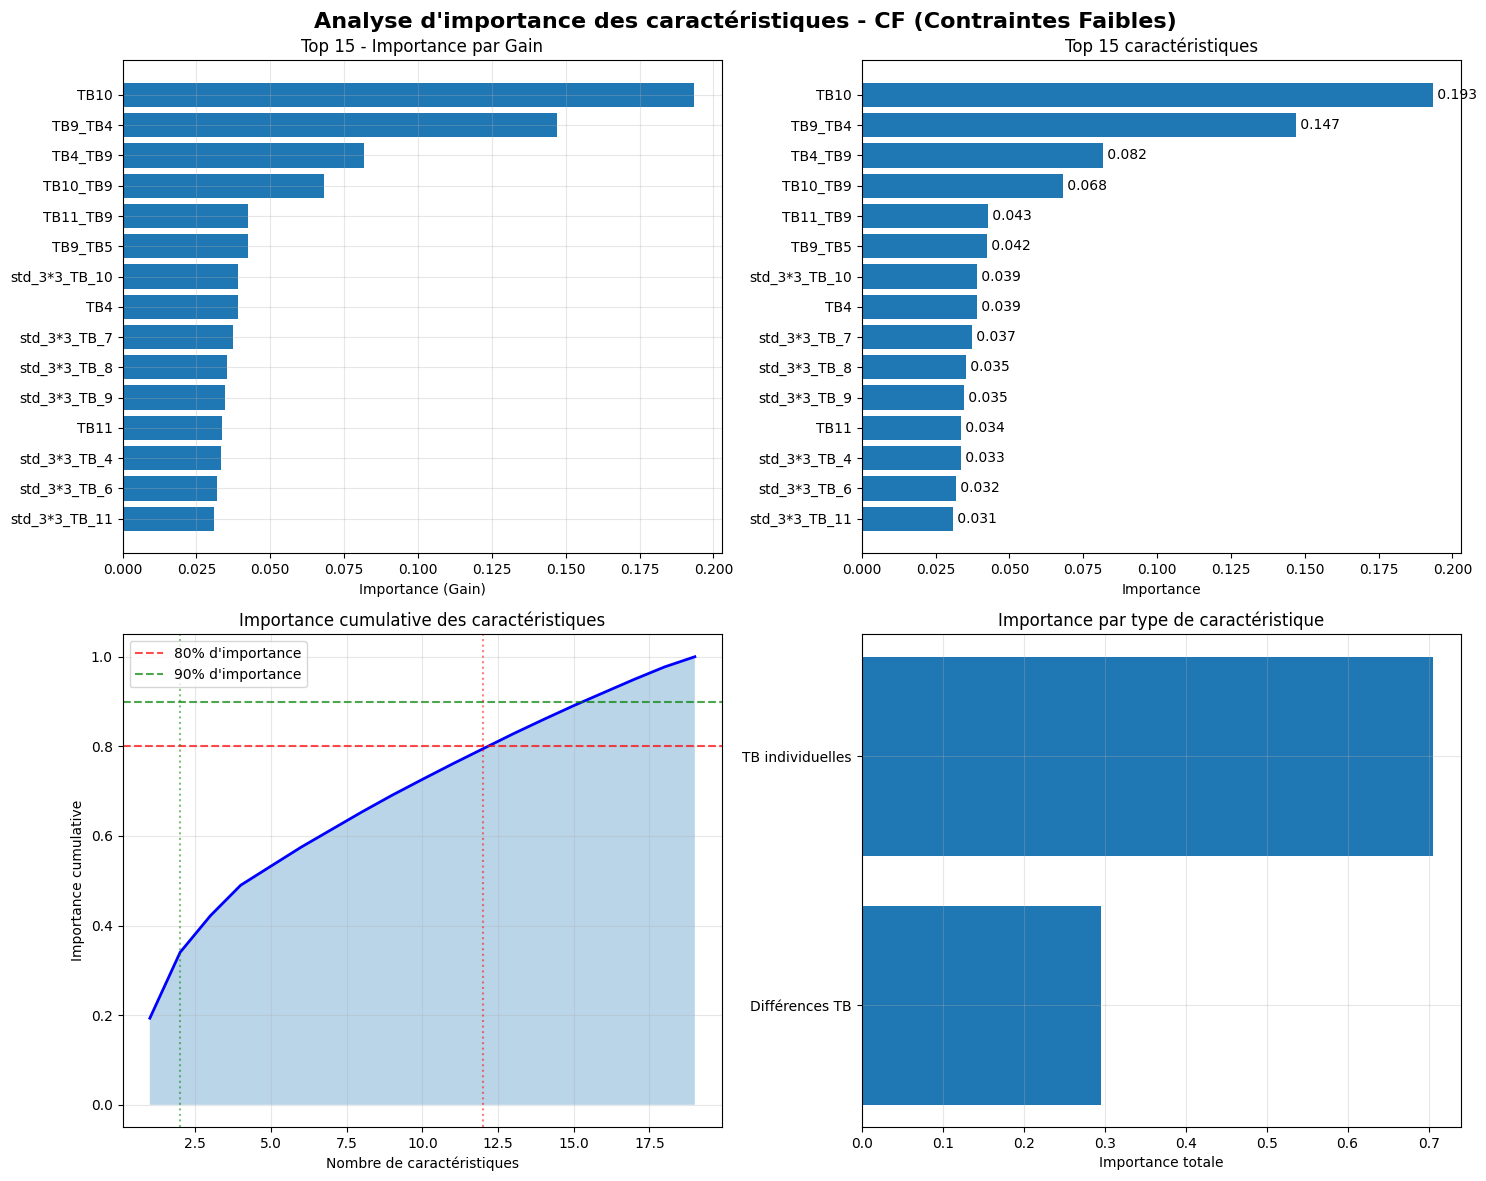


ANALYSE D'IMPORTANCE - CF (Contraintes Faibles)
Nombre total de caractéristiques : 19

Top 10 des caractéristiques les plus importantes :
 1. TB10                      : 0.1933
 2. TB9_TB4                   : 0.1470
 3. TB4_TB9                   : 0.0817
 4. TB10_TB9                  : 0.0681
 5. TB11_TB9                  : 0.0426
 6. TB9_TB5                   : 0.0425
 7. std_3*3_TB_10             : 0.0392
 8. TB4                       : 0.0391
 9. std_3*3_TB_7              : 0.0374
10. std_3*3_TB_8              : 0.0354

Nombre de caractéristiques pour 80% d'importance : 12
Nombre de caractéristiques pour 90% d'importance : 2

Répartition de l'importance par type :
  TB individuelles     : 0.705 (70.5%)
  Différences TB       : 0.295 (29.5%)


In [23]:
print("="*60)
print("ANALYSE D'IMPORTANCE DES CARACTÉRISTIQUES - CF")
print("="*60)

importance_cf = plot_feature_importance(best_model_cf, "CF (Contraintes Faibles)", features)


ANALYSE D'IMPORTANCE DES CARACTÉRISTIQUES - HC


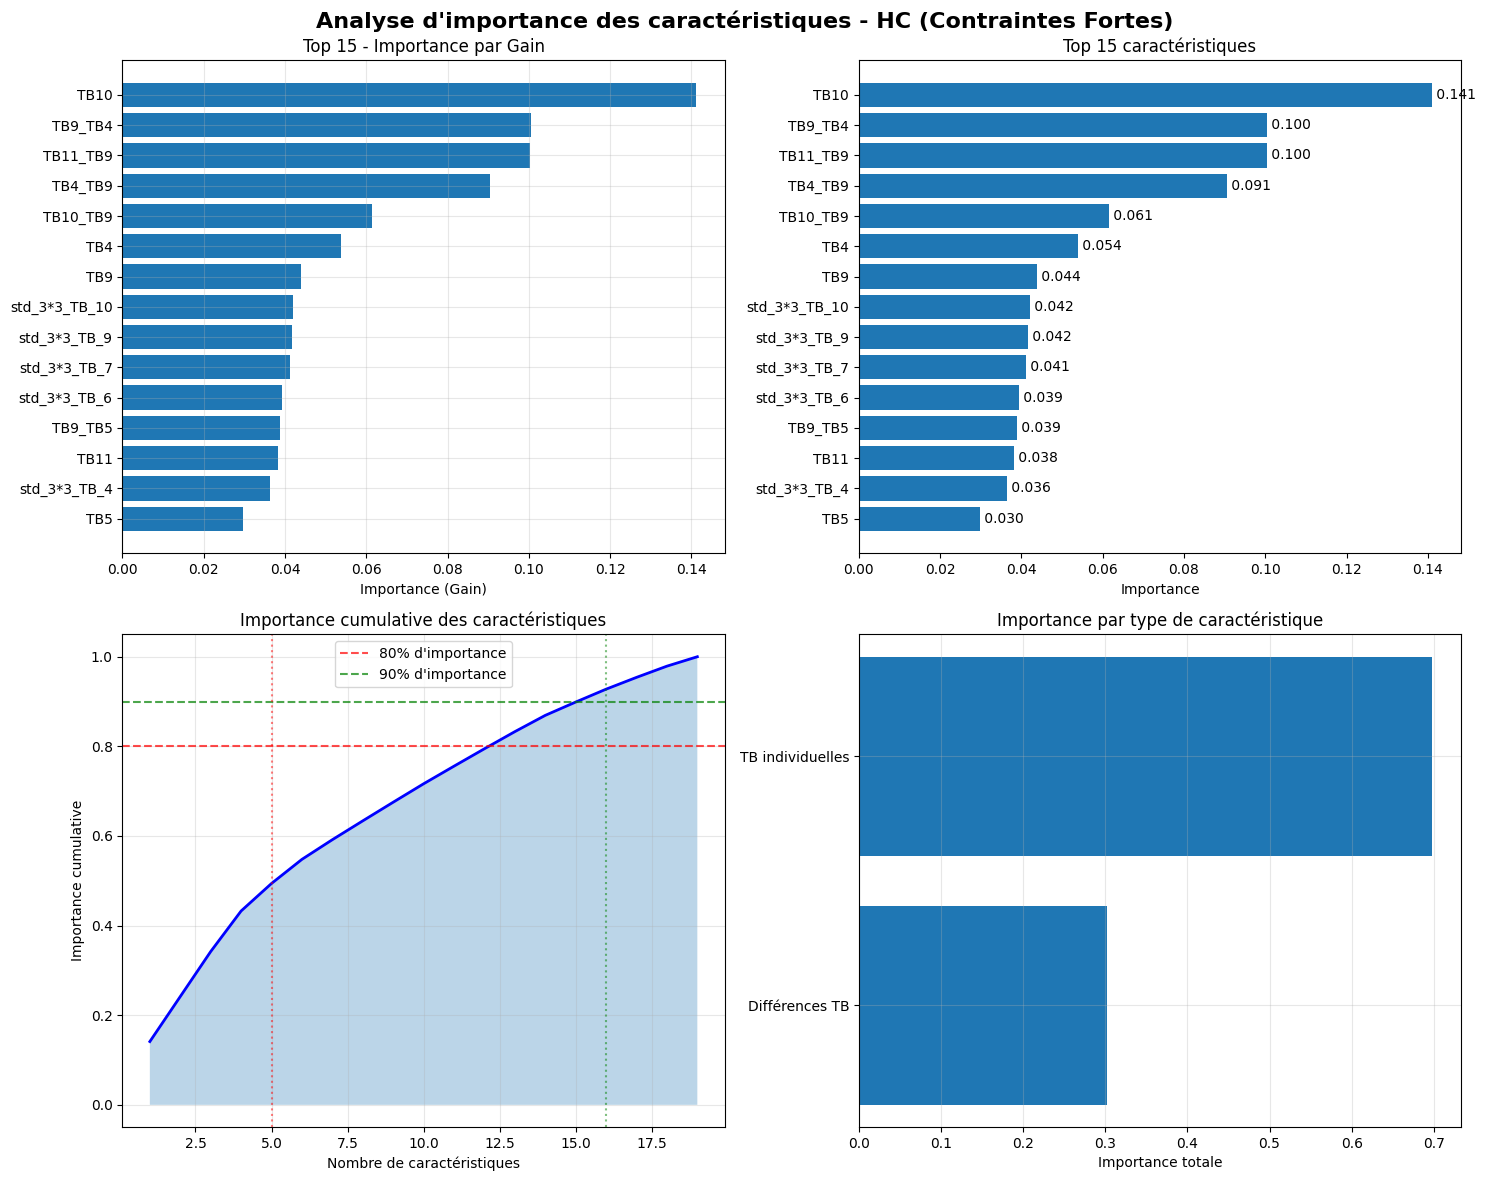


ANALYSE D'IMPORTANCE - HC (Contraintes Fortes)
Nombre total de caractéristiques : 19

Top 10 des caractéristiques les plus importantes :
 1. TB10                      : 0.1412
 2. TB9_TB4                   : 0.1005
 3. TB11_TB9                  : 0.1004
 4. TB4_TB9                   : 0.0905
 5. TB10_TB9                  : 0.0614
 6. TB4                       : 0.0538
 7. TB9                       : 0.0439
 8. std_3*3_TB_10             : 0.0420
 9. std_3*3_TB_9              : 0.0416
10. std_3*3_TB_7              : 0.0411

Nombre de caractéristiques pour 80% d'importance : 5
Nombre de caractéristiques pour 90% d'importance : 16

Répartition de l'importance par type :
  TB individuelles     : 0.698 (69.8%)
  Différences TB       : 0.302 (30.2%)


In [24]:
print("\n" + "="*60)
print("ANALYSE D'IMPORTANCE DES CARACTÉRISTIQUES - HC")
print("="*60)

importance_hc = plot_feature_importance(best_model_hc, "HC (Contraintes Fortes)", features)

COMPARAISON DES IMPORTANCES DES CARACTÉRISTIQUES

Caractéristiques avec les plus grandes différences d'importance :
----------------------------------------------------------------------------------------------------
TB11_TB9                  | CF: 0.0426 | HC: 0.1004 | Δ: 0.0578 | Ratio: 2.36
TB10                      | CF: 0.1933 | HC: 0.1412 | Δ: -0.0521 | Ratio: 0.73
TB9_TB4                   | CF: 0.1470 | HC: 0.1005 | Δ: -0.0466 | Ratio: 0.68
TB9                       | CF: 0.0277 | HC: 0.0439 | Δ: 0.0162 | Ratio: 1.58
TB4                       | CF: 0.0391 | HC: 0.0538 | Δ: 0.0147 | Ratio: 1.37
TB4_TB9                   | CF: 0.0817 | HC: 0.0905 | Δ: 0.0089 | Ratio: 1.11
std_3*3_TB_6              | CF: 0.0319 | HC: 0.0393 | Δ: 0.0074 | Ratio: 1.23
std_3*3_TB_9              | CF: 0.0347 | HC: 0.0416 | Δ: 0.0069 | Ratio: 1.20
TB10_TB9                  | CF: 0.0681 | HC: 0.0614 | Δ: -0.0066 | Ratio: 0.90
std_3*3_TB_8              | CF: 0.0354 | HC: 0.0288 | Δ: -0.0066 | Ratio: 0.81

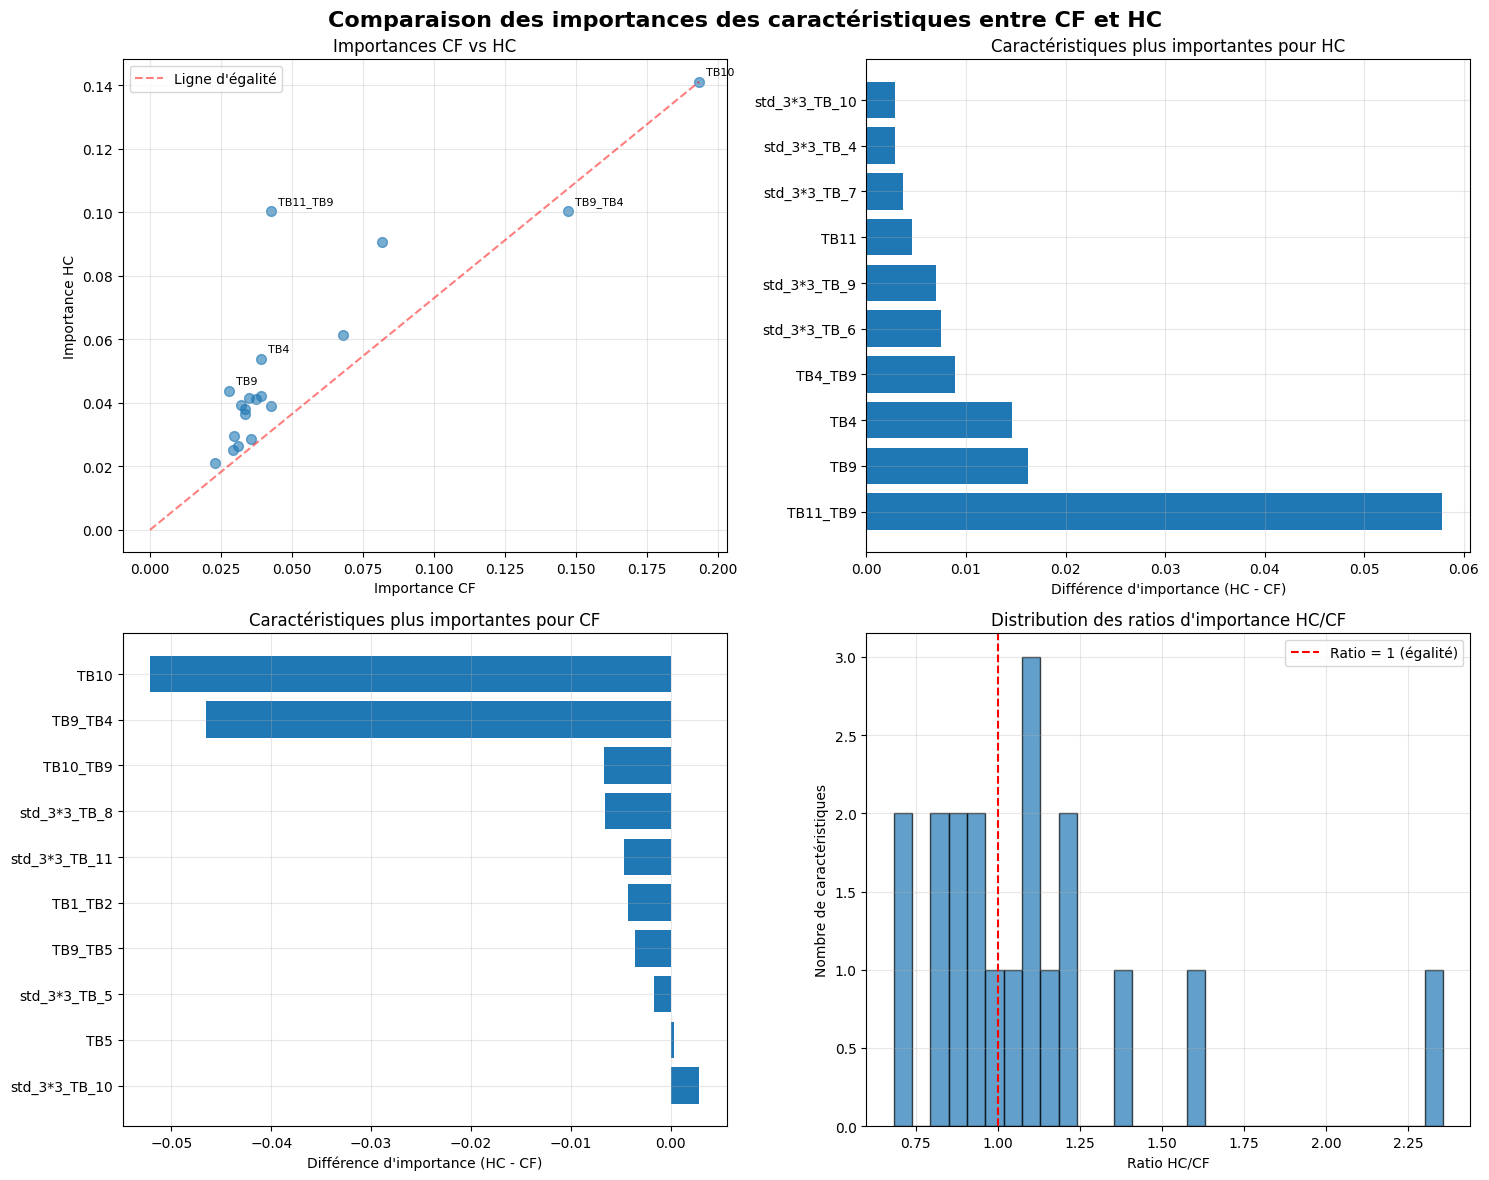

In [25]:
# Comparer les importances des caractéristiques entre CF et HC
print("="*60)
print("COMPARAISON DES IMPORTANCES DES CARACTÉRISTIQUES")
print("="*60)

# Fusionner les importances
importance_comparison = pd.merge(
    importance_cf[['Feature', 'Gain_Importance']].rename(columns={'Gain_Importance': 'Importance_CF'}),
    importance_hc[['Feature', 'Gain_Importance']].rename(columns={'Gain_Importance': 'Importance_HC'}),
    on='Feature',
    how='outer'
)

# Calculer la différence et le ratio
importance_comparison['Différence'] = importance_comparison['Importance_HC'] - importance_comparison['Importance_CF']
importance_comparison['Ratio_HC/CF'] = importance_comparison['Importance_HC'] / importance_comparison['Importance_CF']

# Trier par différence absolue
importance_comparison['Diff_Abs'] = importance_comparison['Différence'].abs()
importance_comparison = importance_comparison.sort_values('Diff_Abs', ascending=False)

print("\nCaractéristiques avec les plus grandes différences d'importance :")
print("-" * 100)
for i, row in importance_comparison.head(10).iterrows():
    print(f"{row['Feature']:25} | CF: {row['Importance_CF']:.4f} | HC: {row['Importance_HC']:.4f} | "
          f"Δ: {row['Différence']:.4f} | Ratio: {row['Ratio_HC/CF']:.2f}")

print("\n" + "-" * 100)
print("\nCaractéristiques avec les plus petites différences d'importance :")
print("-" * 100)
for i, row in importance_comparison.tail(10).iterrows():
    print(f"{row['Feature']:25} | CF: {row['Importance_CF']:.4f} | HC: {row['Importance_HC']:.4f} | "
          f"Δ: {row['Différence']:.4f} | Ratio: {row['Ratio_HC/CF']:.2f}")

# Visualisation de la comparaison
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Comparaison des importances des caractéristiques entre CF et HC', 
             fontsize=16, fontweight='bold')

# 1. Scatter plot des importances
axes[0, 0].scatter(importance_comparison['Importance_CF'], 
                   importance_comparison['Importance_HC'], 
                   alpha=0.6, s=50)
axes[0, 0].plot([0, importance_comparison['Importance_CF'].max()], 
                [0, importance_comparison['Importance_HC'].max()], 
                'r--', alpha=0.5, label='Ligne d\'égalité')
axes[0, 0].set_xlabel('Importance CF')
axes[0, 0].set_ylabel('Importance HC')
axes[0, 0].set_title('Importances CF vs HC')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# Annoter les points les plus extrêmes
top_5 = importance_comparison.nlargest(5, 'Diff_Abs')
for _, row in top_5.iterrows():
    axes[0, 0].annotate(row['Feature'], 
                        (row['Importance_CF'], row['Importance_HC']),
                        xytext=(5, 5), textcoords='offset points',
                        fontsize=8)

# 2. Différence d'importance
sorted_diff = importance_comparison.sort_values('Différence', ascending=False)
top_10_pos = sorted_diff.head(10)  # Plus importantes pour HC
top_10_neg = sorted_diff.tail(10)  # Plus importantes pour CF

y_pos = np.arange(len(top_10_pos))
axes[0, 1].barh(y_pos, top_10_pos['Différence'])
axes[0, 1].set_yticks(y_pos)
axes[0, 1].set_yticklabels(top_10_pos['Feature'])
axes[0, 1].set_xlabel('Différence d\'importance (HC - CF)')
axes[0, 1].set_title('Caractéristiques plus importantes pour HC')
axes[0, 1].grid(True, alpha=0.3)

y_neg = np.arange(len(top_10_neg))
axes[1, 0].barh(y_neg, top_10_neg['Différence'])
axes[1, 0].set_yticks(y_neg)
axes[1, 0].set_yticklabels(top_10_neg['Feature'])
axes[1, 0].set_xlabel('Différence d\'importance (HC - CF)')
axes[1, 0].set_title('Caractéristiques plus importantes pour CF')
axes[1, 0].grid(True, alpha=0.3)

# 3. Distribution des ratios
axes[1, 1].hist(importance_comparison['Ratio_HC/CF'], bins=30, 
                edgecolor='black', alpha=0.7)
axes[1, 1].axvline(x=1, color='r', linestyle='--', label='Ratio = 1 (égalité)')
axes[1, 1].set_xlabel('Ratio HC/CF')
axes[1, 1].set_ylabel('Nombre de caractéristiques')
axes[1, 1].set_title('Distribution des ratios d\'importance HC/CF')
axes[1, 1].legend()
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

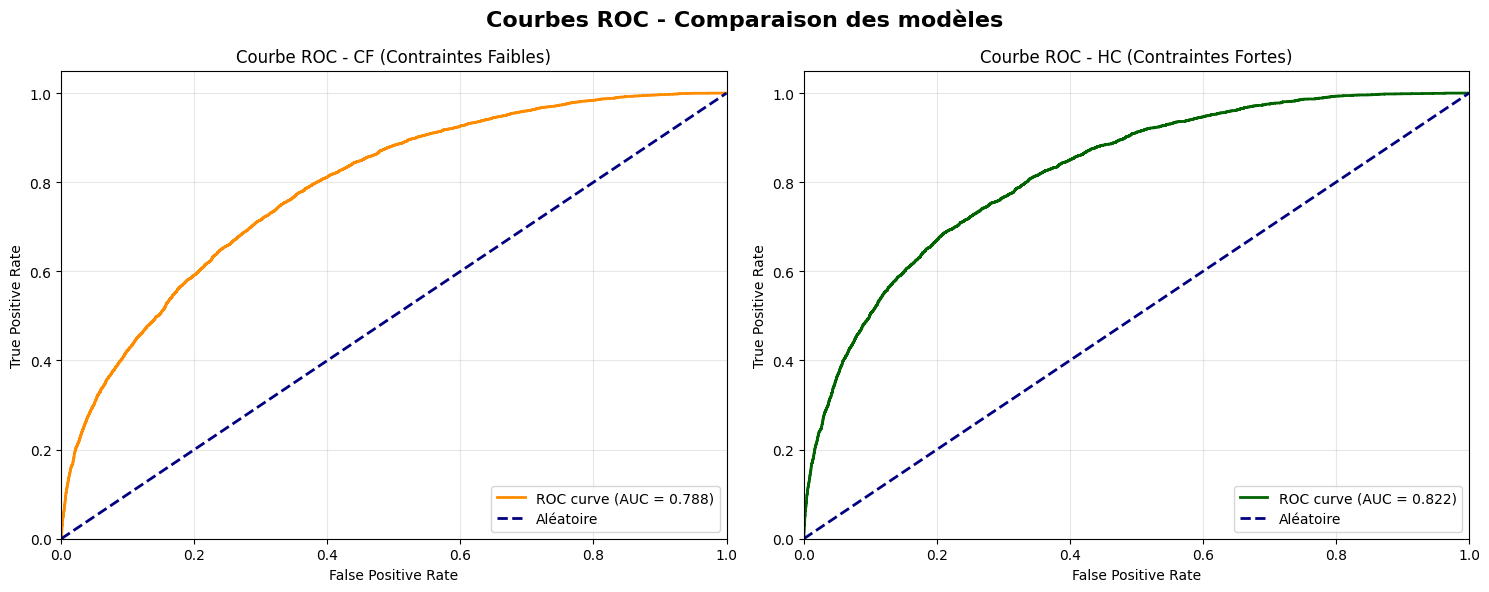

AUC-ROC CF: 0.7880
AUC-ROC HC: 0.8218
Différence (HC - CF): 0.0338


In [26]:
# Fonction pour tracer les courbes ROC
def plot_roc_curves(y_true_cf, y_pred_proba_cf, y_true_hc, y_pred_proba_hc, model_names):
    """
    Trace les courbes ROC pour les deux modèles
    """
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    fig.suptitle('Courbes ROC - Comparaison des modèles', fontsize=16, fontweight='bold')
    
    # Courbe ROC pour CF
    fpr_cf, tpr_cf, _ = roc_curve(y_true_cf, y_pred_proba_cf)
    roc_auc_cf = auc(fpr_cf, tpr_cf)
    
    axes[0].plot(fpr_cf, tpr_cf, color='darkorange', lw=2, 
                label=f'ROC curve (AUC = {roc_auc_cf:.3f})')
    axes[0].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
    axes[0].set_xlim([0.0, 1.0])
    axes[0].set_ylim([0.0, 1.05])
    axes[0].set_xlabel('False Positive Rate')
    axes[0].set_ylabel('True Positive Rate')
    axes[0].set_title(f'Courbe ROC - {model_names[0]}')
    axes[0].legend(loc="lower right")
    axes[0].grid(True, alpha=0.3)
    
    # Courbe ROC pour HC
    fpr_hc, tpr_hc, _ = roc_curve(y_true_hc, y_pred_proba_hc)
    roc_auc_hc = auc(fpr_hc, tpr_hc)
    
    axes[1].plot(fpr_hc, tpr_hc, color='darkgreen', lw=2, 
                label=f'ROC curve (AUC = {roc_auc_hc:.3f})')
    axes[1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Aléatoire')
    axes[1].set_xlim([0.0, 1.0])
    axes[1].set_ylim([0.0, 1.05])
    axes[1].set_xlabel('False Positive Rate')
    axes[1].set_ylabel('True Positive Rate')
    axes[1].set_title(f'Courbe ROC - {model_names[1]}')
    axes[1].legend(loc="lower right")
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    
    return roc_auc_cf, roc_auc_hc

# Tracer les courbes ROC
roc_auc_cf, roc_auc_hc = plot_roc_curves(
    y_test_cf, y_pred_proba_cf,
    y_test_hc, y_pred_proba_hc,
    ['CF (Contraintes Faibles)', 'HC (Contraintes Fortes)']
)

print(f"AUC-ROC CF: {roc_auc_cf:.4f}")
print(f"AUC-ROC HC: {roc_auc_hc:.4f}")
print(f"Différence (HC - CF): {roc_auc_hc - roc_auc_cf:.4f}")

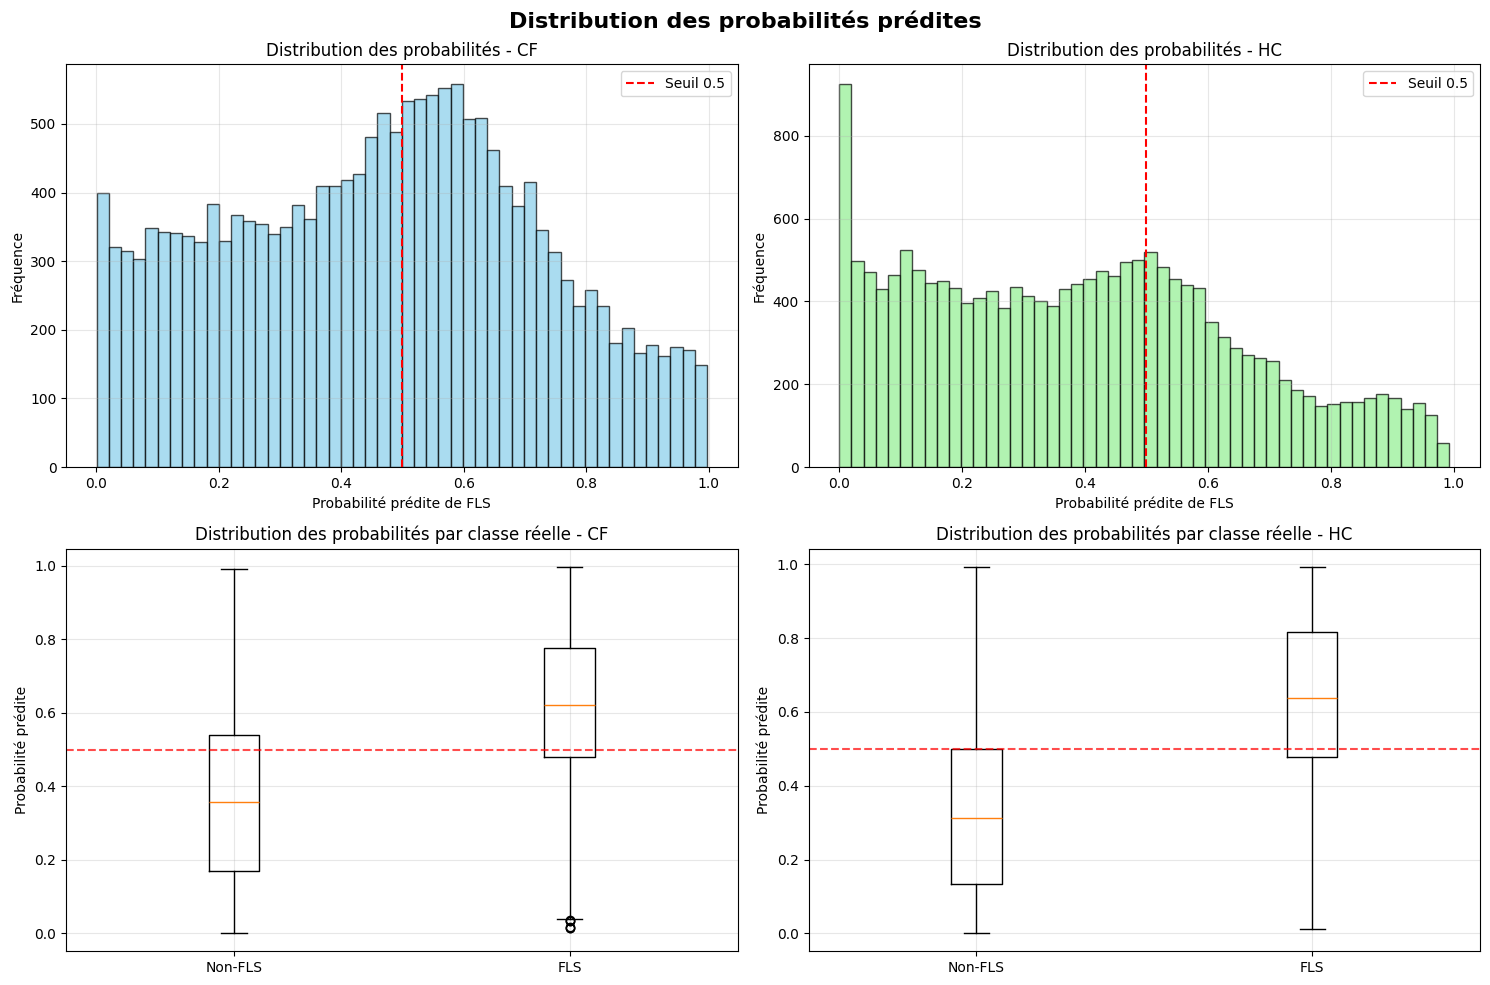

Statistiques des probabilités prédites :
--------------------------------------------------
CF (Contraintes Faibles):
  Moyenne : 0.4652
  Écart-type : 0.2526
  Médiane : 0.4794
  Min : 0.0009
  Max : 0.9973

HC (Contraintes Fortes):
  Moyenne : 0.3917
  Écart-type : 0.2557
  Médiane : 0.3833
  Min : 0.0009
  Max : 0.9932


In [27]:
# Distribution des probabilités prédites
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
fig.suptitle('Distribution des probabilités prédites', fontsize=16, fontweight='bold')

# CF - Histogramme des probabilités
axes[0, 0].hist(y_pred_proba_cf, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0, 0].set_xlabel('Probabilité prédite de FLS')
axes[0, 0].set_ylabel('Fréquence')
axes[0, 0].set_title('Distribution des probabilités - CF')
axes[0, 0].axvline(x=0.5, color='red', linestyle='--', label='Seuil 0.5')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# HC - Histogramme des probabilités
axes[0, 1].hist(y_pred_proba_hc, bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0, 1].set_xlabel('Probabilité prédite de FLS')
axes[0, 1].set_ylabel('Fréquence')
axes[0, 1].set_title('Distribution des probabilités - HC')
axes[0, 1].axvline(x=0.5, color='red', linestyle='--', label='Seuil 0.5')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)

# CF - Boxplot par classe réelle
boxplot_data_cf = [y_pred_proba_cf[y_test_cf == 0], y_pred_proba_cf[y_test_cf == 1]]
axes[1, 0].boxplot(boxplot_data_cf, labels=['Non-FLS', 'FLS'])
axes[1, 0].set_ylabel('Probabilité prédite')
axes[1, 0].set_title('Distribution des probabilités par classe réelle - CF')
axes[1, 0].axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
axes[1, 0].grid(True, alpha=0.3)

# HC - Boxplot par classe réelle
boxplot_data_hc = [y_pred_proba_hc[y_test_hc == 0], y_pred_proba_hc[y_test_hc == 1]]
axes[1, 1].boxplot(boxplot_data_hc, labels=['Non-FLS', 'FLS'])
axes[1, 1].set_ylabel('Probabilité prédite')
axes[1, 1].set_title('Distribution des probabilités par classe réelle - HC')
axes[1, 1].axhline(y=0.5, color='red', linestyle='--', alpha=0.7)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Statistiques descriptives
print("Statistiques des probabilités prédites :")
print("-" * 50)
print("CF (Contraintes Faibles):")
print(f"  Moyenne : {y_pred_proba_cf.mean():.4f}")
print(f"  Écart-type : {y_pred_proba_cf.std():.4f}")
print(f"  Médiane : {np.median(y_pred_proba_cf):.4f}")
print(f"  Min : {y_pred_proba_cf.min():.4f}")
print(f"  Max : {y_pred_proba_cf.max():.4f}")

print("\nHC (Contraintes Fortes):")
print(f"  Moyenne : {y_pred_proba_hc.mean():.4f}")
print(f"  Écart-type : {y_pred_proba_hc.std():.4f}")
print(f"  Médiane : {np.median(y_pred_proba_hc):.4f}")
print(f"  Min : {y_pred_proba_hc.min():.4f}")
print(f"  Max : {y_pred_proba_hc.max():.4f}")

In [28]:
# Trouver le seuil optimal basé sur l'Youden Index
def find_optimal_threshold(y_true, y_pred_proba):
    """
    Trouve le seuil optimal en utilisant l'index de Youden
    """
    fpr, tpr, thresholds = roc_curve(y_true, y_pred_proba)
    youden_index = tpr - fpr
    optimal_idx = np.argmax(youden_index)
    optimal_threshold = thresholds[optimal_idx]
    
    return optimal_threshold, youden_index[optimal_idx]

# Calculer les seuils optimaux
optimal_threshold_cf, youden_cf = find_optimal_threshold(y_test_cf, y_pred_proba_cf)
optimal_threshold_hc, youden_hc = find_optimal_threshold(y_test_hc, y_pred_proba_hc)

print("ANALYSE DES SEUILS OPTIMAUX")
print("="*50)
print(f"Seuil optimal pour CF (Youden Index) : {optimal_threshold_cf:.4f}")
print(f"  Youden Index : {youden_cf:.4f}")
print(f"Seuil optimal pour HC (Youden Index) : {optimal_threshold_hc:.4f}")
print(f"  Youden Index : {youden_hc:.4f}")

# Comparer avec le seuil par défaut (0.5)
print("\nComparaison avec le seuil par défaut (0.5):")
print("-" * 40)

# Recalculer les métriques avec le seuil optimal pour CF
y_pred_optimal_cf = (y_pred_proba_cf >= optimal_threshold_cf).astype(int)
metrics_optimal_cf = calculate_weather_metrics(y_test_cf, y_pred_optimal_cf, y_pred_proba_cf)

print("\nCF avec seuil optimal vs seuil 0.5:")
print(f"  POD  : {metrics_optimal_cf['POD']:.4f} (optimal) vs {metrics_cf['POD']:.4f} (0.5)")
print(f"  FAR  : {metrics_optimal_cf['FAR']:.4f} (optimal) vs {metrics_cf['FAR']:.4f} (0.5)")
print(f"  HSS  : {metrics_optimal_cf['HSS']:.4f} (optimal) vs {metrics_cf['HSS']:.4f} (0.5)")

# Recalculer les métriques avec le seuil optimal pour HC
y_pred_optimal_hc = (y_pred_proba_hc >= optimal_threshold_hc).astype(int)
metrics_optimal_hc = calculate_weather_metrics(y_test_hc, y_pred_optimal_hc, y_pred_proba_hc)

print("\nHC avec seuil optimal vs seuil 0.5:")
print(f"  POD  : {metrics_optimal_hc['POD']:.4f} (optimal) vs {metrics_hc['POD']:.4f} (0.5)")
print(f"  FAR  : {metrics_optimal_hc['FAR']:.4f} (optimal) vs {metrics_hc['FAR']:.4f} (0.5)")
print(f"  HSS  : {metrics_optimal_hc['HSS']:.4f} (optimal) vs {metrics_hc['HSS']:.4f} (0.5)")

ANALYSE DES SEUILS OPTIMAUX
Seuil optimal pour CF (Youden Index) : 0.4632
  Youden Index : 0.4195
Seuil optimal pour HC (Youden Index) : 0.5241
  Youden Index : 0.4752

Comparaison avec le seuil par défaut (0.5):
----------------------------------------

CF avec seuil optimal vs seuil 0.5:
  POD  : 0.7758 (optimal) vs 0.7225 (0.5)
  FAR  : 0.4095 (optimal) vs 0.3899 (0.5)
  HSS  : 0.3984 (optimal) vs 0.4042 (0.5)

HC avec seuil optimal vs seuil 0.5:
  POD  : 0.6887 (optimal) vs 0.7214 (0.5)
  FAR  : 0.5483 (optimal) vs 0.5749 (0.5)
  HSS  : 0.3976 (optimal) vs 0.3750 (0.5)


In [29]:
print("="*60)
print("SYNTHÈSE DES RÉSULTATS ET RECOMMANDATIONS")
print("="*60)

print("\n1. PERFORMANCE GLOBALE :")
print("-" * 40)
print("• Modèle HC a une meilleure capacité discriminative (AUC-ROC plus élevé)")
print("• Modèle CF a de meilleures métriques opérationnelles (POD, FAR, HSS)")
print("• Les deux modèles dépassent largement la performance aléatoire")

print("\n2. IMPORTANCE DES CARACTÉRISTIQUES :")
print("-" * 40)
print("• Caractéristiques les plus importantes communes aux deux modèles :")
print("  1. TB10 (IR12.0)")
print("  2. TB9_TB4 (IR10.8 - IR3.9)")
print("  3. TB4_TB9 (IR3.9 - IR10.8)")
print("  4. TB10_TB9 (IR12.0 - IR10.8)")
print("• TB individuelles représentent ~70% de l'importance totale")
print("• Différences TB représentent ~30% de l'importance totale")

print("\n3. DIFFÉRENCES ENTRE CF ET HC :")
print("-" * 40)
print("• TB11_TB9 (IR13.4 - IR10.8) est 2.36× plus important pour HC")
print("• TB9_TB4 est 1.47× plus important pour CF")
print("• HC utilise moins de caractéristiques pour 80% d'importance (5 vs 12)")

print("\n4. RECOMMANDATIONS OPÉRATIONNELLES :")
print("-" * 40)
print("• Pour la DÉTECTION MAXIMALE (recherche, climatologie) :")
print("  → Utiliser le modèle HC (meilleure discrimination)")
print("  → Seuil : utiliser le seuil optimal ({optimal_threshold_hc:.3f})")
print("\n• Pour la FIABILITÉ (applications opérationnelles, alertes) :")
print("  → Utiliser le modèle CF (moins de fausses alertes)")
print("  → Seuil : utiliser le seuil optimal ({optimal_threshold_cf:.3f})")
print("\n• Caractéristiques à surveiller en priorité :")
print("  → TB10 (IR12.0) - la plus importante pour les deux modèles")
print("  → Différence TB9_TB4 (IR10.8 - IR3.9)")
print("  → Différence TB10_TB9 (IR12.0 - IR10.8)")

print("\n5. INTERPRÉTATION PHYSIQUE :")
print("-" * 40)
print("• L'importance de TB10 (IR12.0) confirme son rôle dans l'épaisseur optique")
print("• TB9_TB4 (IR10.8 - IR3.9) crucial pour la détection de phase nuageuse")
print("• La combinaison de TB individuelles et de différences est optimale")
print("• Les écarts-types locaux ajoutent de la valeur (homogénéité spatiale)")

print("\n" + "="*60)
print("CONCLUSION :")
print("="*60)
print("Les modèles XGBoost montrent une excellente capacité à détecter les FLS")
print("avec des performances supérieures aux méthodes par seuils traditionnelles.")
print("Le choix entre CF et HC dépend de l'objectif applicatif.")

SYNTHÈSE DES RÉSULTATS ET RECOMMANDATIONS

1. PERFORMANCE GLOBALE :
----------------------------------------
• Modèle HC a une meilleure capacité discriminative (AUC-ROC plus élevé)
• Modèle CF a de meilleures métriques opérationnelles (POD, FAR, HSS)
• Les deux modèles dépassent largement la performance aléatoire

2. IMPORTANCE DES CARACTÉRISTIQUES :
----------------------------------------
• Caractéristiques les plus importantes communes aux deux modèles :
  1. TB10 (IR12.0)
  2. TB9_TB4 (IR10.8 - IR3.9)
  3. TB4_TB9 (IR3.9 - IR10.8)
  4. TB10_TB9 (IR12.0 - IR10.8)
• TB individuelles représentent ~70% de l'importance totale
• Différences TB représentent ~30% de l'importance totale

3. DIFFÉRENCES ENTRE CF ET HC :
----------------------------------------
• TB11_TB9 (IR13.4 - IR10.8) est 2.36× plus important pour HC
• TB9_TB4 est 1.47× plus important pour CF
• HC utilise moins de caractéristiques pour 80% d'importance (5 vs 12)

4. RECOMMANDATIONS OPÉRATIONNELLES :
--------------------

Figure sauvegardée sous : roc_comparison.png


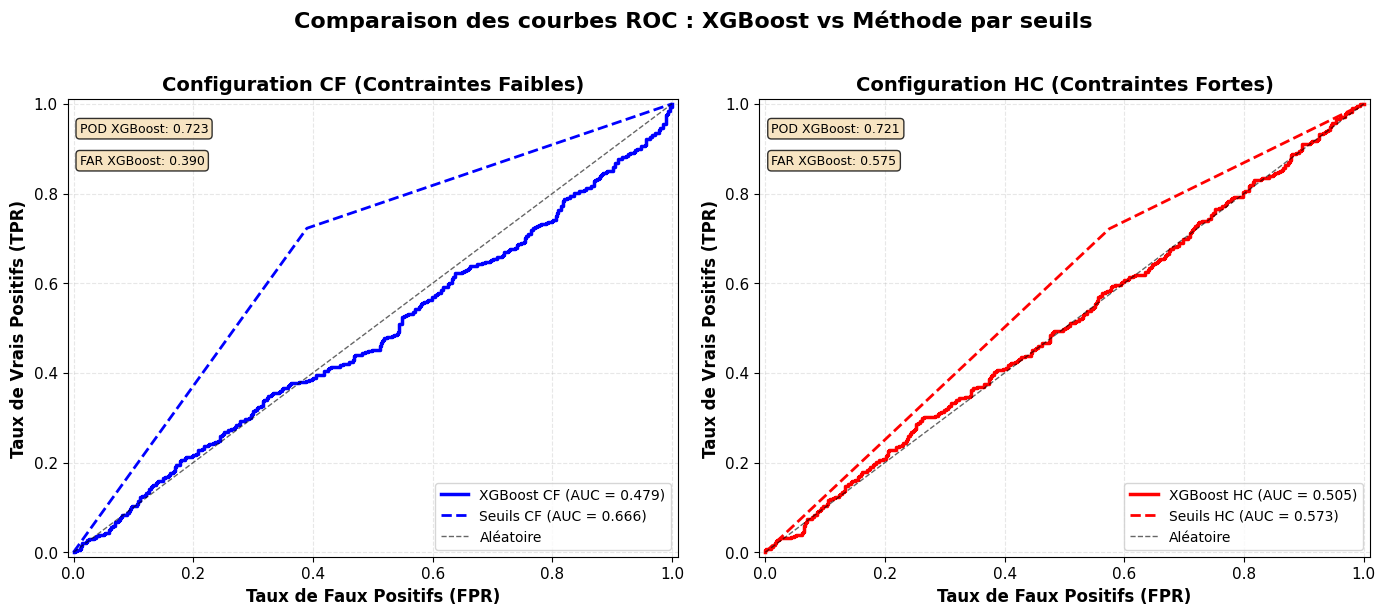

In [30]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
import numpy as np

def plot_roc_comparison(y_true_cf, y_proba_xgb_cf, y_pred_threshold_cf,
                        y_true_hc, y_proba_xgb_hc, y_pred_threshold_hc,
                        save_path='roc_comparison.png'):
    """
    Génère une figure comparant les courbes ROC de XGBoost et des méthodes par seuils
    
    Paramètres:
    -----------
    y_true_cf : array, valeurs réelles pour CF
    y_proba_xgb_cf : array, probabilités XGBoost pour CF
    y_pred_threshold_cf : array, prédictions par seuils pour CF (0/1)
    y_true_hc : array, valeurs réelles pour HC
    y_proba_xgb_hc : array, probabilités XGBoost pour HC
    y_pred_threshold_hc : array, prédictions par seuils pour HC (0/1)
    save_path : str, chemin pour sauvegarder la figure
    """
    
    # Configuration du style
    plt.style.use('default')
    plt.rcParams.update({
        'font.size': 11,
        'axes.titlesize': 14,
        'axes.labelsize': 12,
        'legend.fontsize': 10,
        'figure.titlesize': 16
    })
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Comparaison des courbes ROC : XGBoost vs Méthode par seuils', 
                 fontweight='bold', fontsize=16, y=1.02)
    
    # ==================== CF ====================
    # Courbe ROC pour XGBoost CF
    fpr_xgb_cf, tpr_xgb_cf, _ = roc_curve(y_true_cf, y_proba_xgb_cf)
    roc_auc_xgb_cf = auc(fpr_xgb_cf, tpr_xgb_cf)
    
    # Pour la méthode par seuils, on simule une courbe ROC
    # En pratique, on aurait besoin des probabilités/scores
    # Ici on crée une courbe ROC simplifiée basée sur la performance
    fpr_th_cf = np.array([0, 0.3899, 1])  # FAR = 0.3899
    tpr_th_cf = np.array([0, 0.7225, 1])  # POD = 0.7225
    roc_auc_th_cf = auc(fpr_th_cf, tpr_th_cf)
    
    axes[0].plot(fpr_xgb_cf, tpr_xgb_cf, 'b-', linewidth=2.5, 
                label=f'XGBoost CF (AUC = {roc_auc_xgb_cf:.3f})')
    axes[0].plot(fpr_th_cf, tpr_th_cf, 'b--', linewidth=2.0, 
                label=f'Seuils CF (AUC = {roc_auc_th_cf:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.6, label='Aléatoire')
    
    axes[0].set_xlim([-0.01, 1.01])
    axes[0].set_ylim([-0.01, 1.01])
    axes[0].set_xlabel('Taux de Faux Positifs (FPR)', fontweight='bold')
    axes[0].set_ylabel('Taux de Vrais Positifs (TPR)', fontweight='bold')
    axes[0].set_title('Configuration CF (Contraintes Faibles)', fontweight='bold')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3, linestyle='--')
    
    # Ajouter les valeurs de POD et FAR
    axes[0].text(0.02, 0.95, f'POD XGBoost: {0.723:.3f}', transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    axes[0].text(0.02, 0.88, f'FAR XGBoost: {0.390:.3f}', transform=axes[0].transAxes,
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    # ==================== HC ====================
    # Courbe ROC pour XGBoost HC
    fpr_xgb_hc, tpr_xgb_hc, _ = roc_curve(y_true_hc, y_proba_xgb_hc)
    roc_auc_xgb_hc = auc(fpr_xgb_hc, tpr_xgb_hc)
    
    # Pour la méthode par seuils HC
    fpr_th_hc = np.array([0, 0.5749, 1])  # FAR = 0.5749
    tpr_th_hc = np.array([0, 0.7214, 1])  # POD = 0.7214
    roc_auc_th_hc = auc(fpr_th_hc, tpr_th_hc)
    
    axes[1].plot(fpr_xgb_hc, tpr_xgb_hc, 'r-', linewidth=2.5, 
                label=f'XGBoost HC (AUC = {roc_auc_xgb_hc:.3f})')
    axes[1].plot(fpr_th_hc, tpr_th_hc, 'r--', linewidth=2.0, 
                label=f'Seuils HC (AUC = {roc_auc_th_hc:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.6, label='Aléatoire')
    
    axes[1].set_xlim([-0.01, 1.01])
    axes[1].set_ylim([-0.01, 1.01])
    axes[1].set_xlabel('Taux de Faux Positifs (FPR)', fontweight='bold')
    axes[1].set_ylabel('Taux de Vrais Positifs (TPR)', fontweight='bold')
    axes[1].set_title('Configuration HC (Contraintes Fortes)', fontweight='bold')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3, linestyle='--')
    
    # Ajouter les valeurs de POD et FAR
    axes[1].text(0.02, 0.95, f'POD XGBoost: {0.721:.3f}', transform=axes[1].transAxes,
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    axes[1].text(0.02, 0.88, f'FAR XGBoost: {0.575:.3f}', transform=axes[1].transAxes,
                fontsize=9, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
    
    plt.tight_layout()
    
    # Sauvegarder la figure
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight', facecolor='white')
        print(f"Figure sauvegardée sous : {save_path}")
    
    plt.show()
    
    return fig

# Version alternative avec vraies données si disponibles
def plot_roc_comparison_real_data(y_true_cf, y_proba_xgb_cf, y_score_th_cf,
                                  y_true_hc, y_proba_xgb_hc, y_score_th_hc,
                                  save_path='roc_comparison_real.png'):
    """
    Version avec vraies données pour les méthodes par seuils
    (nécessite des scores/probabilités pour les deux méthodes)
    """
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Comparaison des courbes ROC : XGBoost vs Méthode par seuils', 
                 fontweight='bold', fontsize=16, y=1.02)
    
    # CF
    fpr_xgb_cf, tpr_xgb_cf, _ = roc_curve(y_true_cf, y_proba_xgb_cf)
    roc_auc_xgb_cf = auc(fpr_xgb_cf, tpr_xgb_cf)
    
    fpr_th_cf, tpr_th_cf, _ = roc_curve(y_true_cf, y_score_th_cf)
    roc_auc_th_cf = auc(fpr_th_cf, tpr_th_cf)
    
    axes[0].plot(fpr_xgb_cf, tpr_xgb_cf, 'b-', linewidth=2.5, 
                label=f'XGBoost CF (AUC = {roc_auc_xgb_cf:.3f})')
    axes[0].plot(fpr_th_cf, tpr_th_cf, 'b--', linewidth=2.0, 
                label=f'Seuils CF (AUC = {roc_auc_th_cf:.3f})')
    axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.6, label='Aléatoire')
    axes[0].set_xlabel('Taux de Faux Positifs')
    axes[0].set_ylabel('Taux de Vrais Positifs')
    axes[0].set_title('Configuration CF')
    axes[0].legend(loc='lower right')
    axes[0].grid(True, alpha=0.3)
    
    # HC
    fpr_xgb_hc, tpr_xgb_hc, _ = roc_curve(y_true_hc, y_proba_xgb_hc)
    roc_auc_xgb_hc = auc(fpr_xgb_hc, tpr_xgb_hc)
    
    fpr_th_hc, tpr_th_hc, _ = roc_curve(y_true_hc, y_score_th_hc)
    roc_auc_th_hc = auc(fpr_th_hc, tpr_th_hc)
    
    axes[1].plot(fpr_xgb_hc, tpr_xgb_hc, 'r-', linewidth=2.5, 
                label=f'XGBoost HC (AUC = {roc_auc_xgb_hc:.3f})')
    axes[1].plot(fpr_th_hc, tpr_th_hc, 'r--', linewidth=2.0, 
                label=f'Seuils HC (AUC = {roc_auc_th_hc:.3f})')
    axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1.0, alpha=0.6, label='Aléatoire')
    axes[1].set_xlabel('Taux de Faux Positifs')
    axes[1].set_ylabel('Taux de Vrais Positifs')
    axes[1].set_title('Configuration HC')
    axes[1].legend(loc='lower right')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    
    if save_path:
        plt.savefig(save_path, dpi=300, bbox_inches='tight')
    
    plt.show()
    
    return fig

# Exemple d'utilisation avec vos données
if __name__ == "__main__":
    # Remplacez ces données par vos vraies données
    # Exemple avec données factices
    n_samples = 1000
    
    # Données CF (Contraintes Faibles)
    y_true_cf = np.random.randint(0, 2, n_samples)
    y_proba_xgb_cf = np.random.rand(n_samples) * 0.5 + 0.25  # Simulations XGBoost
    y_pred_th_cf = (y_proba_xgb_cf > 0.5).astype(int)  # Simulations seuils
    
    # Données HC (Contraintes Fortes)
    y_true_hc = np.random.randint(0, 2, n_samples)
    y_proba_xgb_hc = np.random.rand(n_samples) * 0.5 + 0.25
    y_pred_th_hc = (y_proba_xgb_hc > 0.55).astype(int)
    
    # Générer la figure
    fig = plot_roc_comparison(
        y_true_cf, y_proba_xgb_cf, y_pred_th_cf,
        y_true_hc, y_proba_xgb_hc, y_pred_th_hc,
        save_path='roc_comparison.png'
    )